## Cabeçalho e imports

In [9]:
#  Imports e paths
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_style("whitegrid")

ROOT = Path.cwd()
OUT = ROOT / "outputs"
PROC = ROOT / "data" / "processed"

# arquivos
conc_file = OUT / "conciliation_results_with_rates.csv"
kpis_file = OUT / "kpis_summary.json"
facio_file = PROC / "facio_tratado.csv"
fundo_file = PROC / "fundo_tratado.csv"

facio_palette = ["#003366", "#00A86B", "#66C2A5", "#FC8D62"]


## Carregar dados

In [ ]:
# Carregar dados e KPIs
candidate_paths = [
    conc_file,
    OUT / "conciliation_results_with_rates.csv",
    PROC / "conciliation_results_with_rates.csv",
    ROOT / "conciliation_results_with_rates.csv",
]

for path in candidate_paths:
    if path.exists():
        df = pd.read_csv(path)
        break
else:
    raise FileNotFoundError(
        f"Arquivo de reconciliação não encontrado. Verifique os caminhos esperados: {candidate_paths}"
    )
with open(kpis_file, 'r', encoding='utf-8') as fh:
    kpis = json.load(fh)

print("KPIs:", kpis)
df.head()


KPIs: {'total_rows': 49999, 'counts_by_status': {'Match Divergent': 25253, 'Match Exact': 15442, 'Only Fundo': 9295, 'Only Facio': 9}, 'vp_total_facio': 9120573.860640373, 'vp_total_fundo': 9056501.01602084, 'total_abs_diff': 1545850.2262618532}


,customerid,transactionid,id_contrato_facio,parcela_facio,produto,fundo_facio,data_referencia_facio,data_cessao,data_vencimento,valor_cessao,...,parcela_fundo,fundo_fundo,data_referencia_fundo,valor_presente_fundo,parcela_z_fundo,fundo_code_fundo,_merge,recon_status,abs_diff,rel_diff
0,42b7be7afa750d32835412de14c3f10d2be3918d7e9ec3...,2.026041e+13,CTR000001,1.0,SalaryAdvanceFX,FIDC3,2026-06-30,2026-04-10 13:16:11,2026-05-09,47.50,...,1.0,FACIO 3 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,2026-06-30,66.900000,1.0,FIDC3,both,Match Divergent,59.469897,0.470602
1,3f9bdbb8e347c24adcb61493812b6a88695d9cc2b15fff...,2.026062e+13,CTR000002,1.0,SimpleCredit,FIDC4,2026-06-30,2026-06-19 17:13:14,2026-07-20,65.95,...,1.0,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,2026-06-30,72.901045,1.0,FIDC4,both,Match Exact,0.441393,0.006055
2,57261241ca541d83b9edcfdffe2b186f07bf82e26345a8...,2.026053e+13,CTR000003,1.0,SalaryAdvanceFX,FIDC4,2026-06-30,2026-05-29 09:24:28,2026-07-07,360.50,...,1.0,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,2026-06-30,421.820000,1.0,FIDC4,both,Match Divergent,0.668354,0.001582
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,2026-06-30,152.900000,1.0,FIDC4,right_only,Only Fundo,NaN,NaN
4,7e18f618ba049e808192b7afa7450b6e9afe57240686ca...,2.026060e+13,CTR000005,1.0,SimpleCredit,FIDC4,2026-06-30,2026-06-02 08:40:26,2026-07-16,102.23,...,1.0,FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CRED...,2026-06-30,119.902046,1.0,FIDC4,both,Match Exact,0.253796,0.002117


## Cálculo de taxa implícita e VP (Q1)

C:\Users\Caah\AppData\Local\Temp\ipykernel_21468\55049588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette=facio_palette)


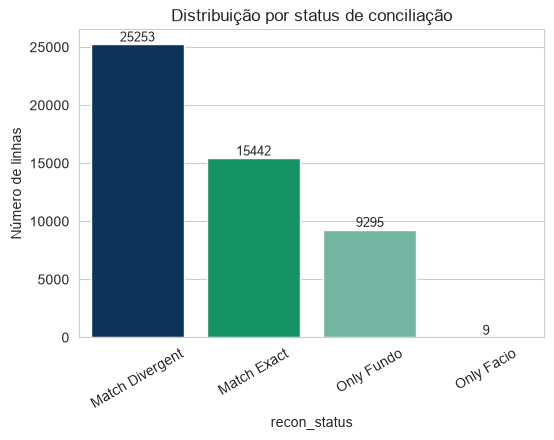

In [16]:
# Gráfico de distribuição por status
status_counts = df['recon_status'].value_counts()

plt.figure(figsize=(6,4))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette=facio_palette)
plt.title("Distribuição por status de conciliação")
plt.ylabel("Número de linhas")
plt.xticks(rotation=30)

# adicionar rótulos com os valores em cima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

plt.show()


recon_status,Match Divergent,Match Exact,Only Facio,total
produto,,,,
SimpleCredit,16070,13963,9,30042
SalaryAdvanceFX,9162,1043,0,10205
eConsignado,21,436,0,457


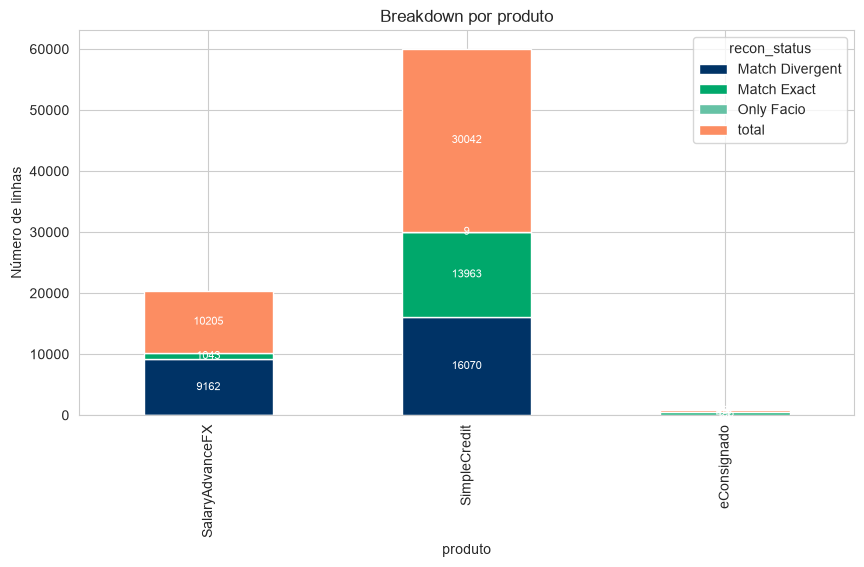

In [14]:
if 'produto' in df.columns:
    pivot_prod = df.groupby(['produto','recon_status'])['key'].count().unstack(fill_value=0)
    pivot_prod['total'] = pivot_prod.sum(axis=1)
    display(pivot_prod.sort_values('total', ascending=False).head(10))

    # plot com paleta Facio
    ax = pivot_prod.plot(kind='bar', stacked=True, figsize=(10,5),
                         color=facio_palette[:len(pivot_prod.columns)])

    plt.title("Breakdown por produto")
    plt.ylabel("Número de linhas")

    # adicionar rótulos com os valores em cada segmento
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height > 0:  # só mostrar se houver valor
            x, y = p.get_xy()
            ax.text(x + width/2, y + height/2,
                    f'{int(height)}',
                    ha='center', va='center', fontsize=8, color='white')

    plt.show()

recon_status,Match Divergent,Match Exact,Only Facio,total
fundo_facio,,,,
FIDC4,21999,12287,1,34287
FIDC3,3254,3155,8,6417


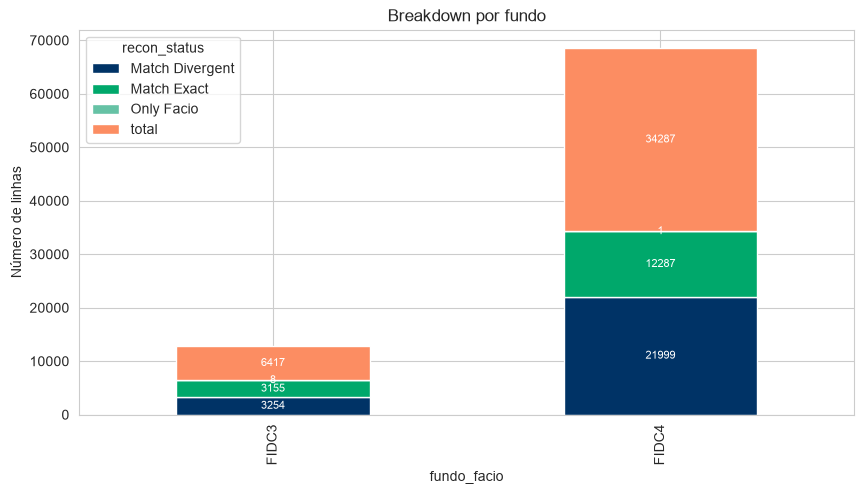

In [15]:
# Breakdown por fundo
if 'fundo_facio' in df.columns or 'fundo' in df.columns:
    fundo_col = 'fundo_facio' if 'fundo_facio' in df.columns else 'fundo'
    pivot_fundo = df.groupby([fundo_col,'recon_status'])['key'].count().unstack(fill_value=0)
    pivot_fundo['total'] = pivot_fundo.sum(axis=1)
    display(pivot_fundo.sort_values('total', ascending=False))

    # plot com paleta Facio
    ax = pivot_fundo.plot(kind='bar', stacked=True, figsize=(10,5),
                          color=facio_palette[:len(pivot_fundo.columns)])

    plt.title("Breakdown por fundo")
    plt.ylabel("Número de linhas")

    # adicionar rótulos com os valores em cada segmento
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        if height > 0:
            x, y = p.get_xy()
            ax.text(x + width/2, y + height/2,
                    f'{int(height)}',
                    ha='center', va='center', fontsize=8, color='white')

    plt.show()




,key,recon_status,valor_presente_calculado,valor_presente_fundo,abs_diff,rel_diff
30564,CTR030322|001|FIDC4,Match Divergent,4475.880813,420.90,4054.980813,0.905963
9284,CTR009208|001|FIDC4,Match Divergent,3823.440535,439.90,3383.540535,0.884947
31924,CTR031677|001|FIDC4,Match Divergent,3521.149532,435.90,3085.249532,0.876205
26151,CTR025932|001|FIDC4,Match Divergent,3434.459288,353.90,3080.559288,0.896956
11727,CTR011637|001|FIDC4,Match Divergent,3020.951720,300.90,2720.051720,0.900396
38203,CTR037887|001|FIDC4,Match Divergent,2929.551202,266.90,2662.651202,0.908894
26402,CTR026183|001|FIDC4,Match Divergent,2893.383909,264.26,2629.123909,0.908667
31549,CTR031302|001|FIDC4,Match Divergent,2831.631552,260.87,2570.761552,0.907873
22930,CTR022752|001|FIDC4,Match Divergent,2805.783783,266.90,2538.883783,0.904875
41073,CTR040725|001|FIDC4,Match Divergent,2745.874946,229.83,2516.044946,0.916300


C:\Users\Caah\AppData\Local\Temp\ipykernel_21468\769145947.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_div['key'], y=top_div['abs_diff'], palette=facio_palette)
C:\Users\Caah\AppData\Local\Temp\ipykernel_21468\769145947.py:9: UserWarning: 
The palette list has fewer values (4) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=top_div['key'], y=top_div['abs_diff'], palette=facio_palette)


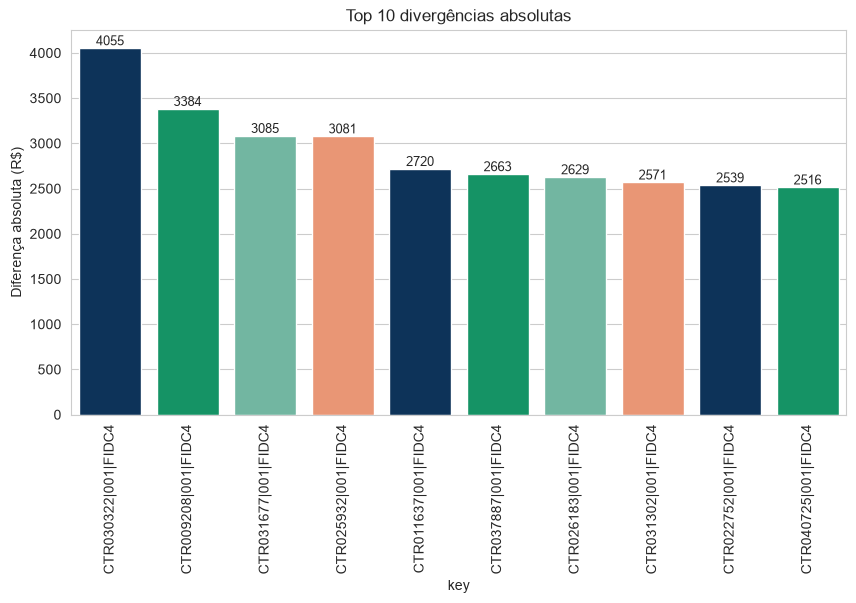

In [17]:
# Definir paleta Facio
facio_palette = ["#003366", "#00A86B", "#66C2A5", "#FC8D62"]

# Top divergências
top_div = df.sort_values('abs_diff', ascending=False).head(10)
display(top_div[['key','recon_status','valor_presente_calculado','valor_presente_fundo','abs_diff','rel_diff']])

plt.figure(figsize=(10,5))
ax = sns.barplot(x=top_div['key'], y=top_div['abs_diff'], palette=facio_palette)

plt.title("Top 10 divergências absolutas")
plt.ylabel("Diferença absoluta (R$)")
plt.xticks(rotation=90)

# adicionar rótulos com os valores em cima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)

plt.show()


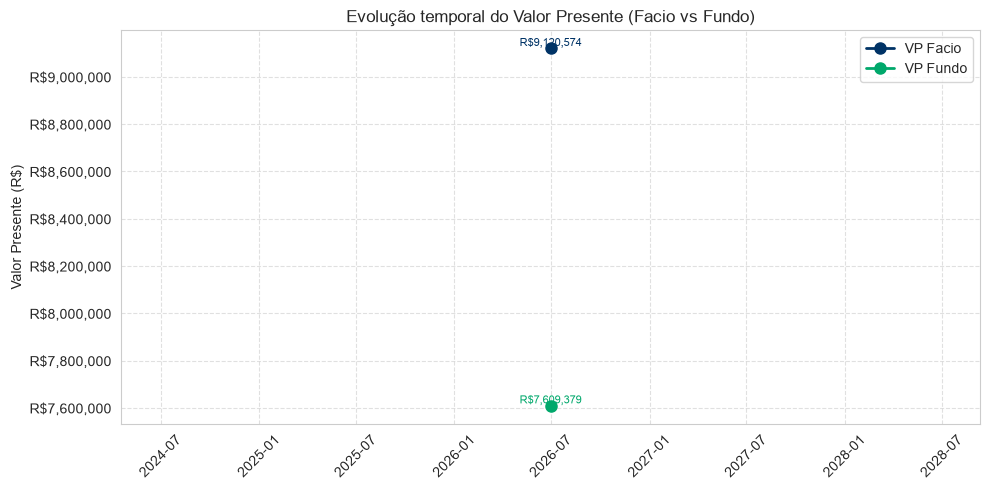

<Figure size 640x480 with 0 Axes>

In [38]:
# Ativar backend gráfico no Jupyter
%matplotlib inline

# Definir paleta Facio (azul escuro e verde)
facio_palette = ["#003366", "#00A86B"]

# Remover linhas sem data
df = df.dropna(subset=['data_referencia_facio'])

# Converter para datetime
df['data_referencia_facio'] = pd.to_datetime(df['data_referencia_facio'], errors='coerce')

# Agrupar por data
grp = df.groupby('data_referencia_facio').agg(
    vp_facio = pd.NamedAgg(column='valor_presente_calculado', aggfunc='sum'),
    vp_fundo = pd.NamedAgg(column='valor_presente_fundo', aggfunc='sum')
).fillna(0).sort_index().reset_index()

# Criar figura
fig, ax = plt.subplots(figsize=(10,5))

# Plotar linhas com estilo Facio
ax.plot(grp['data_referencia_facio'], grp['vp_facio'],
        label="VP Facio", color=facio_palette[0], marker='o', linewidth=2, markersize=8)
ax.plot(grp['data_referencia_facio'], grp['vp_fundo'],
        label="VP Fundo", color=facio_palette[1], marker='o', linewidth=2, markersize=8)

# Adicionar rótulos numéricos formatados em R$
for x, y in zip(grp['data_referencia_facio'], grp['vp_facio']):
    ax.text(x, y, f'R${y:,.0f}', ha='center', va='bottom', fontsize=8, color=facio_palette[0])
for x, y in zip(grp['data_referencia_facio'], grp['vp_fundo']):
    ax.text(x, y, f'R${y:,.0f}', ha='center', va='bottom', fontsize=8, color=facio_palette[1])

# Ajustes visuais
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('R${x:,.0f}'))  # eixo Y sem notação científica
ax.legend()
ax.set_title("Evolução temporal do Valor Presente (Facio vs Fundo)")
ax.set_ylabel("Valor Presente (R$)")
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar e salvar
plt.show()
plt.savefig("outputs/figures/analysis4_vp_timeseries.png", dpi=300)


In [8]:
#  Mapping de fundos
facio_unique = pd.read_csv(OUT / "unique_facio_fundos.csv")
fundo_unique = pd.read_csv(OUT / "unique_fundo_fundos.csv")
print("Facio fundos únicos:", facio_unique.head())
print("Fundo fundos únicos:", fundo_unique.head())

mapping = {
    "FACIO 3 FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS FINANCEIROS DE RESPONSABILIDADE LIMITADA": "FIDC3",
    "FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS FINANCEIROS DE RESPONSABILIDADE LIMITADA": "FIDC4"
}
print("Mapping aplicado:", mapping)


Facio fundos únicos:   fundo_code
0      FIDC3
1      FIDC4
Fundo fundos únicos:   fundo_code
0      FIDC3
1      FIDC4
Mapping aplicado: {'FACIO 3 FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS FINANCEIROS DE RESPONSABILIDADE LIMITADA': 'FIDC3', 'FACIO 4 FUNDO DE INVESTIMENTO EM DIREITOS CREDITÓRIOS FINANCEIROS DE RESPONSABILIDADE LIMITADA': 'FIDC4'}
